In [1]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape)

(891, 12)


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 891
Columns: 12


In [5]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [6]:
df.dtypes


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.sort_values(ascending=False))

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


In [9]:
print(df["Survived"].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


In [10]:
print(df["Survived"].value_counts(normalize=True) * 100)

Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


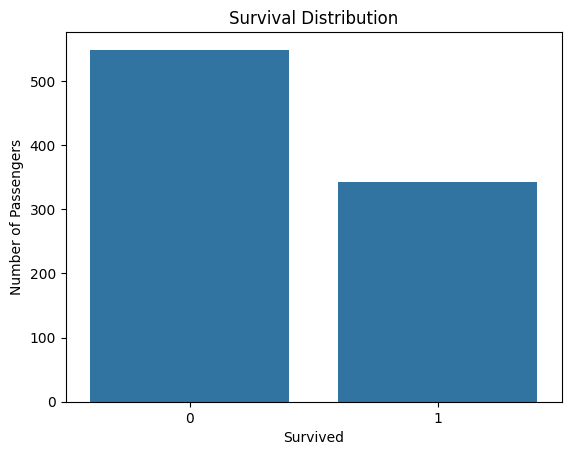

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

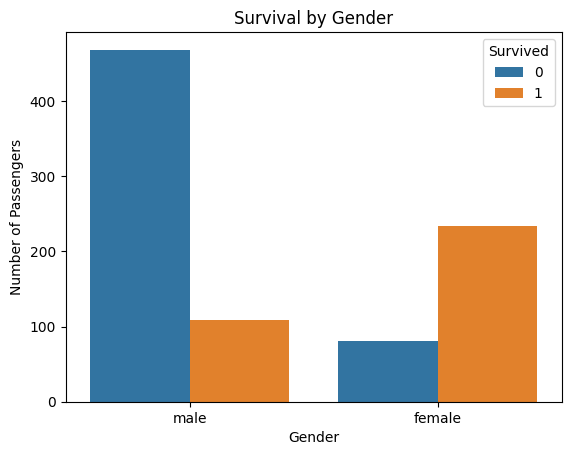

In [12]:
sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

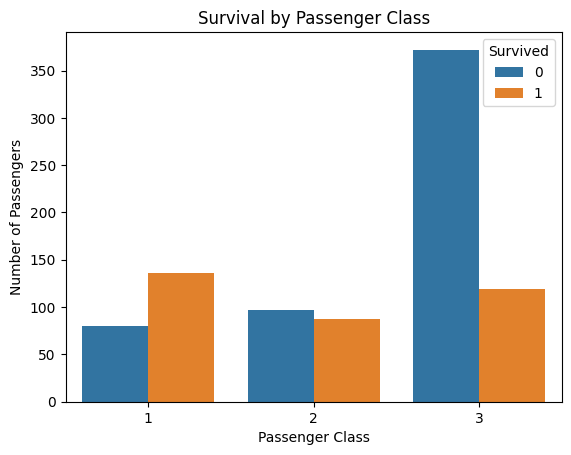

In [13]:
sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

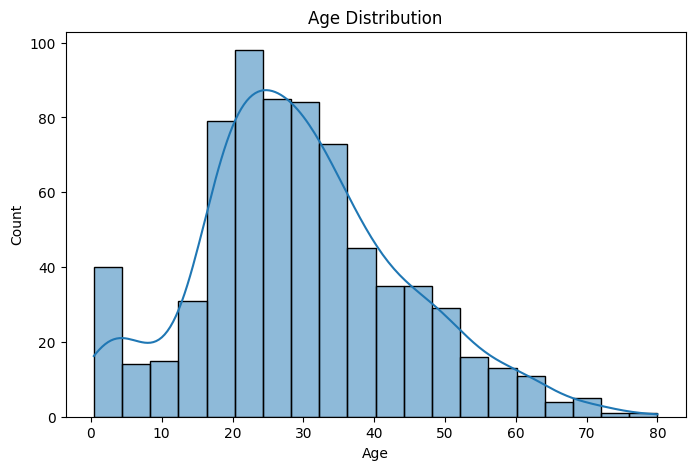

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

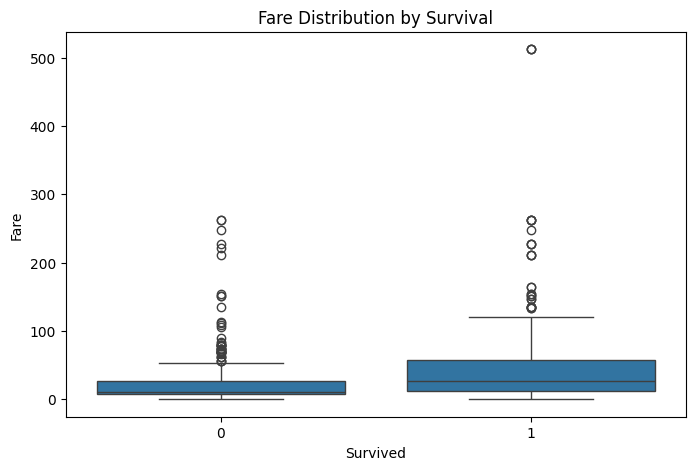

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Survived", y="Fare")

plt.title("Fare Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

In [16]:
df = df.drop(columns=["Cabin"])

In [17]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
df["Age"].isnull().sum()

np.int64(177)

In [19]:
df["Embarked"].isnull().sum()

np.int64(2)

In [20]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64


In [21]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 179


In [22]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [23]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [24]:
from google.colab import files

uploaded = files.upload()

In [25]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [26]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [27]:
df[["SibSp", "Parch", "FamilySize", "IsAlone"]].head(10)

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1
5,0,0,1,1
6,0,0,1,1
7,3,1,5,0
8,0,2,3,0
9,1,0,2,0


✅ Libraries imported successfully!

========== DATASET INFORMATION ==========
Dataset Shape: (891, 13)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'FamilySize', 'IsAlone']

Missing Values:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
dtype: int64

Total Missing Values: 0

========== FEATURE ENGINEERING ==========
   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1

========== FEATURES & TARGET ==========
X Shape: (891, 12)
y Shape: (891,)

Target Distribution:
Survived
0    549
1    342
Name: count, dtype: int64

Target Percentage:
Survived
0    61.616162
1    38.383838
Nam

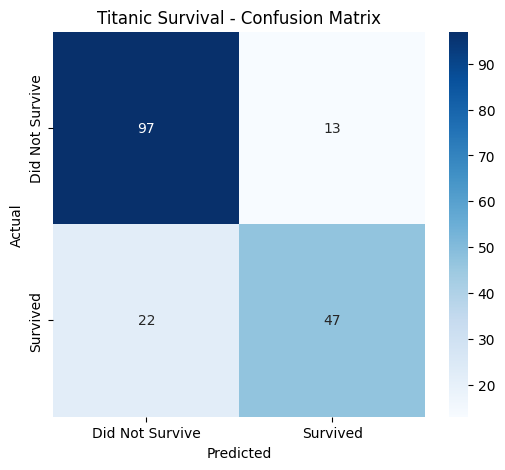


========== ROC CURVE ==========


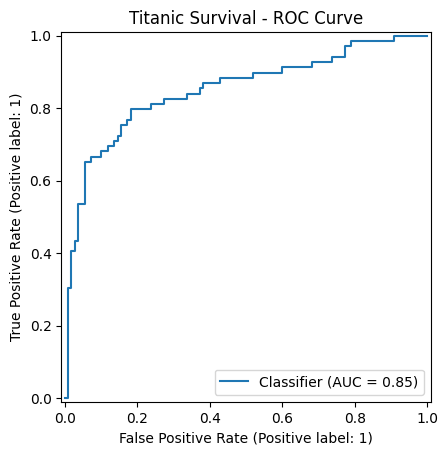


========== CROSS VALIDATION ==========
5-Fold CV Scores:
[0.78212291 0.76966292 0.79775281 0.78089888 0.83146067]

Mean CV Accuracy: 0.7924
CV Standard Deviation: 0.0215

========== OVERFITTING CHECK ==========
Training Accuracy: 0.8020
Testing Accuracy : 0.8045
Accuracy Difference: -0.0025
✅ No major overfitting detected.

🚢 TITANIC SURVIVAL PREDICTION - FINAL RESULT
Accuracy  : 80.45%
Precision : 78.33%
Recall    : 68.12%
F1 Score  : 72.87%
ROC-AUC   : 85.09%

5-Fold CV Mean Accuracy: 79.24%

✅ END-TO-END ML PROJECT COMPLETED!


In [28]:
# ============================================================
# 🚢 TITANIC SURVIVAL PREDICTION
# Week 3 - Machine Learning Mini Project
# End-to-End ML Workflow
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

print("✅ Libraries imported successfully!")


# ------------------------------------------------------------
# 2. VERIFY DATASET
# ------------------------------------------------------------

print("\n========== DATASET INFORMATION ==========")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())


# ------------------------------------------------------------
# 3. FEATURE ENGINEERING
# ------------------------------------------------------------

# FamilySize
if "FamilySize" not in df.columns:
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# IsAlone
if "IsAlone" not in df.columns:
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

print("\n========== FEATURE ENGINEERING ==========")

print(df[[
    "SibSp",
    "Parch",
    "FamilySize",
    "IsAlone"
]].head())


# ------------------------------------------------------------
# 4. DEFINE FEATURES (X) AND TARGET (y)
# ------------------------------------------------------------

X = df.drop(columns=["Survived"])
y = df["Survived"]

print("\n========== FEATURES & TARGET ==========")

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts())

print("\nTarget Percentage:")
print(y.value_counts(normalize=True) * 100)


# ------------------------------------------------------------
# 5. IDENTIFY NUMERICAL & CATEGORICAL FEATURES
# ------------------------------------------------------------

numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

categorical_features = [
    "Sex",
    "Embarked"
]

print("\n========== FEATURE TYPES ==========")

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)


# ------------------------------------------------------------
# 6. TRAIN / TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n========== TRAIN / TEST SPLIT ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 7. PREPROCESSING
# ------------------------------------------------------------

# Numerical → StandardScaler
# Categorical → OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

print("\n========== PREPROCESSING ==========")
print("✅ Numerical features → StandardScaler")
print("✅ Categorical features → OneHotEncoder")


# ------------------------------------------------------------
# 8. CREATE MACHINE LEARNING PIPELINE
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", model)
    ]
)

print("\n========== MODEL ==========")
print("Algorithm: Logistic Regression")
print("Regularization: L2 (default)")


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

print("\n========== TRAINING MODEL ==========")

pipeline.fit(X_train, y_train)

print("✅ Model trained successfully!")


# ------------------------------------------------------------
# 10. MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = pipeline.predict(X_test)

# Probability of survival
y_probability = pipeline.predict_proba(X_test)[:, 1]

print("\n========== PREDICTIONS ==========")

print("First 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predicted Values:")
print(y_pred[:10])


# ------------------------------------------------------------
# 11. EVALUATION METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\n========== MODEL EVALUATION ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")


# ------------------------------------------------------------
# 12. CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Did Not Survive",
            "Survived"
        ]
    )
)


# ------------------------------------------------------------
# 13. CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\n========== CONFUSION MATRIX ==========")

print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Did Not Survive",
        "Survived"
    ],
    yticklabels=[
        "Did Not Survive",
        "Survived"
    ]
)

plt.title("Titanic Survival - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ------------------------------------------------------------
# 14. ROC CURVE
# ------------------------------------------------------------

print("\n========== ROC CURVE ==========")

RocCurveDisplay.from_predictions(
    y_test,
    y_probability
)

plt.title("Titanic Survival - ROC Curve")
plt.show()


# ------------------------------------------------------------
# 15. CROSS VALIDATION
# ------------------------------------------------------------

print("\n========== CROSS VALIDATION ==========")

cv_scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("5-Fold CV Scores:")
print(cv_scores)

print("\nMean CV Accuracy:",
      round(cv_scores.mean(), 4))

print("CV Standard Deviation:",
      round(cv_scores.std(), 4))


# ------------------------------------------------------------
# 16. OVERFITTING CHECK
# ------------------------------------------------------------

train_predictions = pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_predictions
)

test_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n========== OVERFITTING CHECK ==========")

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")

difference = train_accuracy - test_accuracy

print(f"Accuracy Difference: {difference:.4f}")

if difference > 0.10:
    print("⚠️ Possible overfitting detected.")
else:
    print("✅ No major overfitting detected.")


# ------------------------------------------------------------
# 17. FINAL RESULT
# ------------------------------------------------------------

print("\n==============================================")
print("🚢 TITANIC SURVIVAL PREDICTION - FINAL RESULT")
print("==============================================")

print(f"Accuracy  : {accuracy:.2%}")
print(f"Precision : {precision:.2%}")
print(f"Recall    : {recall:.2%}")
print(f"F1 Score  : {f1:.2%}")
print(f"ROC-AUC   : {roc_auc:.2%}")

print(f"\n5-Fold CV Mean Accuracy: {cv_scores.mean():.2%}")

print("\n==============================================")
print("✅ END-TO-END ML PROJECT COMPLETED!")
print("==============================================")

# 🚢 Project Conclusion

## Titanic Survival Prediction

In this project, I developed an end-to-end Machine Learning classification model to predict passenger survival using the Titanic dataset.

### 🔄 Workflow

The project followed a complete Machine Learning workflow:

Dataset Loading → Exploratory Data Analysis → Data Cleaning → Feature Engineering → Encoding → Train/Test Split → Feature Scaling → Model Training → Prediction → Evaluation → Cross Validation

### 🛠️ Data Preprocessing

The dataset was analyzed for missing values and unnecessary columns.

- Missing Age values were handled using the median.
- Missing Embarked values were handled using the mode.
- Cabin was removed because of extensive missing data.
- FamilySize and IsAlone were created through feature engineering.
- Categorical features were encoded using OneHotEncoder.
- Numerical features were standardized using StandardScaler.

### 🤖 Machine Learning Model

Logistic Regression was used as the classification algorithm.

### 📊 Model Performance

| Metric | Score |
|---|---:|
| Accuracy | 80.45% |
| Precision | 78.33% |
| Recall | 68.12% |
| F1 Score | 72.87% |
| ROC-AUC | 85.09% |
| 5-Fold CV Accuracy | 79.24% |

### 🔍 Model Validation

5-Fold Cross Validation produced an average accuracy of 79.24% with a standard deviation of 2.15%.

The training accuracy was 80.20% and testing accuracy was 80.45%, showing no major overfitting signal for this model and dataset.

### 💡 Key Learning

This project helped demonstrate that Machine Learning is not only about training a model. A reliable ML workflow requires:

- Understanding the dataset
- Cleaning and preparing data
- Creating useful features
- Proper train/test splitting
- Preventing data leakage
- Scaling numerical features
- Encoding categorical features
- Selecting appropriate evaluation metrics
- Validating model performance

## ✅ Final Outcome

The Titanic Survival Prediction project successfully demonstrated an end-to-end supervised Machine Learning classification workflow using Python and Scikit-learn.